# Exploring `Anthropic/EconomicIndex` — Corrected

Based on actual file structure confirmed from the repository.

| File | Confirmed columns |
|------|-------------------|
| `labor_market_impacts/job_exposure.csv` | `occ_code`, `title`, `observed_exposure` |
| `labor_market_impacts/task_penetration.csv` | `task`, `penetration` |
| `release_2025_02_10/wage_data.csv` | inspect in Section 2 |
| `release_2025_02_10/bls_employment_may_2023.csv` | inspect in Section 2 |
| `release_2025_02_10/onet_task_mappings.csv` | inspect in Section 2 |
| `release_2025_02_10/onet_task_statements.csv` | inspect in Section 2 |
| `release_2025_02_10/automation_vs_augmentation.csv` | inspect in Section 2 |
| `release_2025_03_27/task_pct_v2.csv` | inspect in Section 3 |
| `release_2025_03_27/automation_vs_augmentation_by_task.csv` | inspect in Section 3 |
| `release_2025_03_27/task_thinking_fractions.csv` | inspect in Section 3 |
| `release_2025_09_15/data/output/aei_enriched_claude_ai_*.csv` | inspect in Section 4 |
| `release_2026_01_15/data/intermediate/aei_raw_*.csv` | inspect in Section 5 |

In [2]:
# !pip install huggingface_hub pandas matplotlib seaborn -q

from huggingface_hub import hf_hub_download
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

REPO = 'Anthropic/EconomicIndex'
REPO_TYPE = 'dataset'

def load(path, sep=','):
    local = hf_hub_download(repo_id=REPO, filename=path, repo_type=REPO_TYPE)
    df = pd.read_csv(local, sep=sep)
    print(f'FILE: {path}')
    print(f'  shape : {df.shape}')
    print(f'  cols  : {df.columns.tolist()}')
    print()
    return df

print('Ready.')

Ready.


---
## Section 1 — Labor Market Impacts
The two files directly tied to Massenkoff & McCrory (2026).

In [3]:
job_exposure = load('labor_market_impacts/job_exposure.csv')
display(job_exposure.head())

FILE: labor_market_impacts/job_exposure.csv
  shape : (756, 3)
  cols  : ['occ_code', 'title', 'observed_exposure']



,occ_code,title,observed_exposure
0,11-1011,Chief Executives,0.0333
1,11-1021,General and Operations Managers,0.1378
2,11-1031,Legislators,0.0000
3,11-2011,Advertising and Promotions Managers,0.1731
4,11-2021,Marketing Managers,0.3195


In [4]:
task_penetration = load('labor_market_impacts/task_penetration.csv')
display(task_penetration.head())

FILE: labor_market_impacts/task_penetration.csv
  shape : (17998, 2)
  cols  : ['task', 'penetration']



,task,penetration
0,Accept and check containers of mail from large...,0.0
1,Accept and check containers of mail or parcels...,0.0
2,Accept credit applications and verify credit r...,0.0
3,Accept music requests from event guests.,0.0
4,"Accept payment from customers, and make change...",0.0


In [5]:
print('=== job_exposure stats ===')
print(job_exposure['observed_exposure'].describe())
n_zero = (job_exposure['observed_exposure'] == 0).sum()
print(f"\nZero exposure: {n_zero} / {len(job_exposure)} occupations ({n_zero/len(job_exposure)*100:.1f}%)")

print('\n=== task_penetration stats ===')
print(task_penetration['penetration'].describe())
n_zero_t = (task_penetration['penetration'] == 0).sum()
print(f"\nZero penetration: {n_zero_t} / {len(task_penetration)} tasks ({n_zero_t/len(task_penetration)*100:.1f}%)")

=== job_exposure stats ===
count    756.000000
mean       0.076977
std        0.133172
min        0.000000
25%        0.000000
50%        0.000000
75%        0.095675
max        0.745100
Name: observed_exposure, dtype: float64

Zero exposure: 411 / 756 occupations (54.4%)

=== task_penetration stats ===
count    17998.000000
mean         0.066744
std          0.235560
min          0.000000
25%          0.000000
50%          0.000000
75%          0.000000
max          1.000000
Name: penetration, dtype: float64

Zero penetration: 16644 / 17998 tasks (92.5%)


In [6]:
print('Top 10 most exposed occupations:')
print(job_exposure.nlargest(10, 'observed_exposure').to_string(index=False))

print('\nBottom 10 non-zero exposed:')
print(job_exposure[job_exposure['observed_exposure'] > 0]
      .nsmallest(10, 'observed_exposure').to_string(index=False))

Top 10 most exposed occupations:
occ_code                                                                                        title  observed_exposure
 15-1251                                                                         Computer Programmers             0.7451
 43-4051                                                             Customer Service Representatives             0.7011
 43-9021                                                                            Data Entry Keyers             0.6707
 29-2072                                                                  Medical Records Specialists             0.6674
 13-1161                                           Market Research Analysts and Marketing Specialists             0.6483
 31-9094                                                                    Medical Transcriptionists             0.6365
 41-4012 Sales Representatives, Wholesale and Manufacturing, Except Technical and Scientific Products             0.6279

In [7]:
print('Top 15 most penetrated tasks:')
print(task_penetration.nlargest(15, 'penetration').to_string(index=False))

Top 15 most penetrated tasks:
                                                                                                                                      task  penetration
                                                                                          Advise customers on use and care of merchandise.          1.0
                                   Advise students on academic and vocational curricula, career issues, and laboratory and field research.          1.0
                                                                         Analyze characteristics of animals to identify and classify them.          1.0
                                                   Analyze data to determine answers to questions from customers or members of the public.          1.0
 Analyze developments in specific field to determine need for revisions in previously published materials and development of new material.          1.0
                                                          

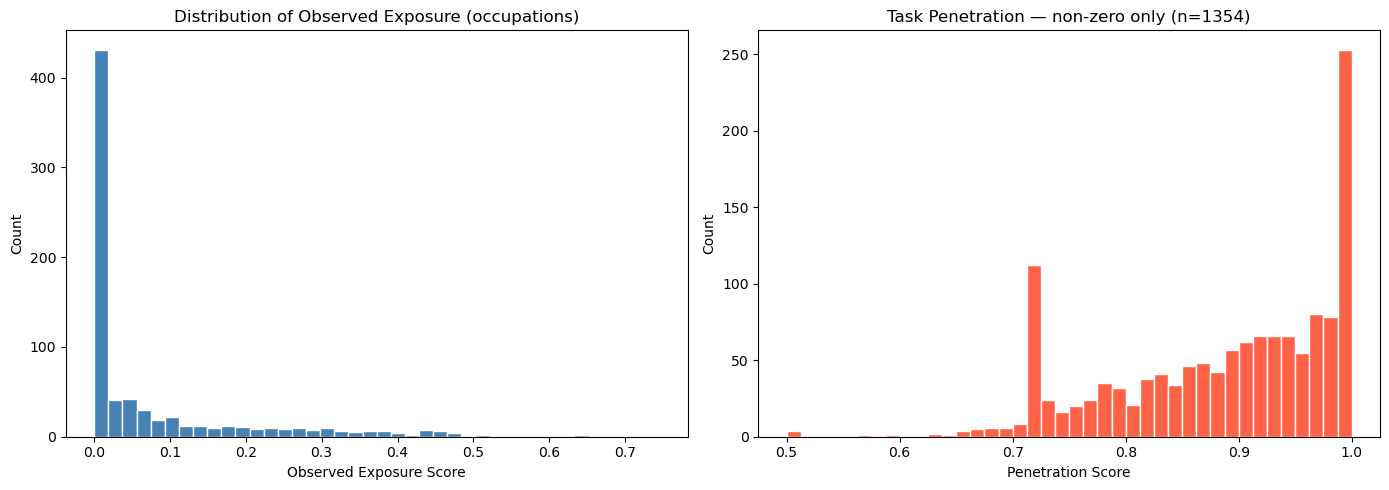

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(job_exposure['observed_exposure'], bins=40, color='steelblue', edgecolor='white')
axes[0].set_title('Distribution of Observed Exposure (occupations)')
axes[0].set_xlabel('Observed Exposure Score')
axes[0].set_ylabel('Count')

nonzero = task_penetration[task_penetration['penetration'] > 0]
axes[1].hist(nonzero['penetration'], bins=40, color='tomato', edgecolor='white')
axes[1].set_title(f'Task Penetration — non-zero only (n={len(nonzero)})')
axes[1].set_xlabel('Penetration Score')
axes[1].set_ylabel('Count')

plt.tight_layout()
plt.show()

---
## Section 2 — Feb 2025 Release
O\*NET mappings, wages, BLS employment, automation vs. augmentation

In [9]:
wages          = load('release_2025_02_10/wage_data.csv')
bls_employment = load('release_2025_02_10/bls_employment_may_2023.csv')
onet_mappings  = load('release_2025_02_10/onet_task_mappings.csv')
onet_tasks     = load('release_2025_02_10/onet_task_statements.csv')
auto_aug       = load('release_2025_02_10/automation_vs_augmentation.csv')
soc            = load('release_2025_02_10/SOC_Structure.csv')

wage_data.csv: 0.00B [00:00, ?B/s]

FILE: release_2025_02_10/wage_data.csv
  shape : (1090, 10)
  cols  : ['SOCcode', 'JobName', 'JobFamily', 'isBright', 'isGreen', 'JobZone', 'MedianSalary', 'JobForecast', 'ChanceAuto', 'WageGroup']



C:\Anaconda\Lib\site-packages\huggingface_hub\file_download.py:129: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\Dionisius Andre\.cache\huggingface\hub\datasets--Anthropic--EconomicIndex. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)


bls_employment_may_2023.csv: 0.00B [00:00, ?B/s]

FILE: release_2025_02_10/bls_employment_may_2023.csv
  shape : (22, 2)
  cols  : ['SOC or O*NET-SOC 2019 Title', 'bls_distribution']



...

FILE: release_2025_02_10/onet_task_statements.csv
  shape : (19530, 8)
  cols  : ['O*NET-SOC Code', 'Title', 'Task ID', 'Task', 'Task Type', 'Incumbents Responding', 'Date', 'Domain Source']



automation_vs_augmentation.csv:   0%|          | 0.00/197 [00:00<?, ?B/s]

FILE: release_2025_02_10/automation_vs_augmentation.csv
  shape : (6, 2)
  cols  : ['interaction_type', 'pct']



SOC_Structure.csv: 0.00B [00:00, ?B/s]

FILE: release_2025_02_10/SOC_Structure.csv
  shape : (1596, 6)
  cols  : ['Major Group', 'Minor Group', 'Broad Occupation', 'Detailed Occupation', 'Detailed O*NET-SOC', 'SOC or O*NET-SOC 2019 Title']



In [10]:
for name, df in [('wages', wages), ('bls_employment', bls_employment),
                 ('onet_mappings', onet_mappings), ('onet_tasks', onet_tasks),
                 ('auto_aug', auto_aug), ('soc', soc)]:
    print(f'--- {name} ---')
    display(df.head(3))
    print()

--- wages ---


,SOCcode,JobName,JobFamily,isBright,isGreen,JobZone,MedianSalary,JobForecast,ChanceAuto,WageGroup
0,13-2011.01,Accountants,Business and Financial Operations,True,False,4,70500.00,146000,-1.0,Accountants and Auditors
1,13-2011.00,Accountants and Auditors,Business and Financial Operations,True,False,-1,70500.00,146000,94.0,NaN
2,27-2011.00,Actors,"Arts, Design, Entertainment, Sports, and Media",False,False,2,17.54,7700,37.0,NaN



--- bls_employment ---


,SOC or O*NET-SOC 2019 Title,bls_distribution
0,Management Occupations,10495770
1,Business and Financial Operations Occupations,10087830
2,Computer and Mathematical Occupations,5177400



--- onet_mappings ---


...

,O*NET-SOC Code,Title,Task ID,Task,Task Type,Incumbents Responding,Date,Domain Source
0,11-1011.00,Chief Executives,8823,Direct or coordinate an organization's financi...,Core,87.0,07/2014,Incumbent
1,11-1011.00,Chief Executives,8831,Appoint department heads or managers and assig...,Core,87.0,07/2014,Incumbent
2,11-1011.00,Chief Executives,8825,Analyze operations to evaluate performance of ...,Core,87.0,07/2014,Incumbent



--- auto_aug ---


,interaction_type,pct
0,directive,22.563272
1,feedback loop,12.036303
2,learning,18.917648



--- soc ---


,Major Group,Minor Group,Broad Occupation,Detailed Occupation,Detailed O*NET-SOC,SOC or O*NET-SOC 2019 Title
0,11-0000,NaN,NaN,NaN,NaN,Management Occupations
1,NaN,11-1000,NaN,NaN,NaN,Top Executives
2,NaN,NaN,11-1010,NaN,NaN,Chief Executives


---
## Section 3 — Mar 2025 Release
Task percentages, automation by task, extended thinking fractions

In [11]:
task_pct     = load('release_2025_03_27/task_pct_v2.csv')
auto_by_task = load('release_2025_03_27/automation_vs_augmentation_by_task.csv')
thinking     = load('release_2025_03_27/task_thinking_fractions.csv')

task_pct_v2.csv: 0.00B [00:00, ?B/s]

FILE: release_2025_03_27/task_pct_v2.csv
  shape : (3365, 2)
  cols  : ['task_name', 'pct']



automation_vs_augmentation_by_task.csv: 0.00B [00:00, ?B/s]

FILE: release_2025_03_27/automation_vs_augmentation_by_task.csv
  shape : (3364, 7)
  cols  : ['task_name', 'feedback_loop', 'directive', 'task_iteration', 'validation', 'learning', 'filtered']



task_thinking_fractions.csv: 0.00B [00:00, ?B/s]

FILE: release_2025_03_27/task_thinking_fractions.csv
  shape : (3365, 2)
  cols  : ['task_name', 'thinking_fraction']



In [12]:
for name, df in [('task_pct', task_pct), ('auto_by_task', auto_by_task), ('thinking', thinking)]:
    print(f'--- {name} ---')
    display(df.head(3))
    print()

--- task_pct ---


,task_name,pct
0,accept commissions to create music for special...,0.002054
1,act as advisers to student organizations.,0.004827
2,act as an advocate for farmers or farmers' gro...,0.001643



--- auto_by_task ---


,task_name,feedback_loop,directive,task_iteration,validation,learning,filtered
0,accept commissions to create music for special...,0.0,0.000000,0.000000,0.0,0.0,1.000000
1,act as advisers to student organizations.,0.0,0.382979,0.361702,0.0,0.0,0.255319
2,act as an advocate for farmers or farmers' gro...,0.0,0.000000,0.000000,0.0,0.0,1.000000



--- thinking ---


,task_name,thinking_fraction
0,accept commissions to create music for special...,NaN
1,act as advisers to student organizations.,NaN
2,act as an advocate for farmers or farmers' gro...,NaN


---
## Section 4 — Sep 2025 Release
Enriched Claude.ai usage data with geographic + API breakdown

In [13]:
aei_sep25 = load('release_2025_09_15/data/output/aei_enriched_claude_ai_2025-08-04_to_2025-08-11.csv')
display(aei_sep25.head(3))

release_2025_09_15/data/output/aei_enric(…):   0%|          | 0.00/26.8M [00:00<?, ?B/s]

FILE: release_2025_09_15/data/output/aei_enriched_claude_ai_2025-08-04_to_2025-08-11.csv
  shape : (136845, 11)
  cols  : ['geo_id', 'geography', 'date_start', 'date_end', 'platform_and_product', 'facet', 'level', 'variable', 'cluster_name', 'value', 'geo_name']



,geo_id,geography,date_start,date_end,platform_and_product,facet,level,variable,cluster_name,value,geo_name
0,ABW,country,2025-08-04,2025-08-11,Claude AI (Free and Pro),country,0,gdp_per_working_age_capita,NaN,55553.993646,Aruba
1,ABW,country,2025-08-04,2025-08-11,Claude AI (Free and Pro),country,0,usage_count,NaN,0.000000,Aruba
2,ABW,country,2025-08-04,2025-08-11,Claude AI (Free and Pro),country,0,usage_pct,NaN,0.000000,Aruba


---
## Section 5 — Jan & Mar 2026 Releases
Raw AEI data with economic primitives (success rate, autonomy, education, complexity)

In [14]:
aei_jan26_ai  = load('release_2026_01_15/data/intermediate/aei_raw_claude_ai_2025-11-13_to_2025-11-20.csv')
aei_jan26_api = load('release_2026_01_15/data/intermediate/aei_raw_1p_api_2025-11-13_to_2025-11-20.csv')

display(aei_jan26_ai.head(3))
display(aei_jan26_api.head(3))

release_2026_01_15/data/intermediate/aei(…):   0%|          | 0.00/94.1M [00:00<?, ?B/s]

FILE: release_2026_01_15/data/intermediate/aei_raw_claude_ai_2025-11-13_to_2025-11-20.csv
  shape : (458778, 10)
  cols  : ['geo_id', 'geography', 'date_start', 'date_end', 'platform_and_product', 'facet', 'level', 'variable', 'cluster_name', 'value']



release_2026_01_15/data/intermediate/aei(…):   0%|          | 0.00/41.5M [00:00<?, ?B/s]

FILE: release_2026_01_15/data/intermediate/aei_raw_1p_api_2025-11-13_to_2025-11-20.csv
  shape : (187772, 10)
  cols  : ['geo_id', 'geography', 'date_start', 'date_end', 'platform_and_product', 'facet', 'level', 'variable', 'cluster_name', 'value']



,geo_id,geography,date_start,date_end,platform_and_product,facet,level,variable,cluster_name,value
0,AD,country,2025-11-13,2025-11-20,Claude AI (Free and Pro),ai_autonomy,0,ai_autonomy_count,NaN,70.000000
1,AD,country,2025-11-13,2025-11-20,Claude AI (Free and Pro),ai_autonomy,0,ai_autonomy_mean,NaN,3.300000
2,AD,country,2025-11-13,2025-11-20,Claude AI (Free and Pro),ai_autonomy,0,ai_autonomy_mean_ci_lower,NaN,3.114286


,geo_id,geography,date_start,date_end,platform_and_product,facet,level,variable,cluster_name,value
0,GLOBAL,global,2025-11-13,2025-11-20,1P API,ai_autonomy,0,ai_autonomy_count,NaN,971450.000000
1,GLOBAL,global,2025-11-13,2025-11-20,1P API,ai_autonomy,0,ai_autonomy_mean,NaN,2.843552
2,GLOBAL,global,2025-11-13,2025-11-20,1P API,ai_autonomy,0,ai_autonomy_mean_ci_lower,NaN,2.841252


In [15]:
aei_mar26_ai  = load('release_2026_03_24/data/aei_raw_claude_ai_2026-02-05_to_2026-02-12.csv')
aei_mar26_api = load('release_2026_03_24/data/aei_raw_1p_api_2026-02-05_to_2026-02-12.csv')

display(aei_mar26_ai.head(3))
display(aei_mar26_api.head(3))

release_2026_03_24/data/aei_raw_claude_a(…):   0%|          | 0.00/96.0M [00:00<?, ?B/s]

FILE: release_2026_03_24/data/aei_raw_claude_ai_2026-02-05_to_2026-02-12.csv
  shape : (425257, 10)
  cols  : ['geo_id', 'geography', 'date_start', 'date_end', 'platform_and_product', 'facet', 'level', 'variable', 'cluster_name', 'value']



release_2026_03_24/data/aei_raw_1p_api_2(…):   0%|          | 0.00/44.0M [00:00<?, ?B/s]

FILE: release_2026_03_24/data/aei_raw_1p_api_2026-02-05_to_2026-02-12.csv
  shape : (195156, 10)
  cols  : ['geo_id', 'geography', 'date_start', 'date_end', 'platform_and_product', 'facet', 'level', 'variable', 'cluster_name', 'value']



,geo_id,geography,date_start,date_end,platform_and_product,facet,level,variable,cluster_name,value
0,AD,country,2026-02-05,2026-02-12,"Claude AI (Free, Pro, and Max)",collaboration,0,collaboration_count,directive,15.00000
1,AD,country,2026-02-05,2026-02-12,"Claude AI (Free, Pro, and Max)",collaboration,0,collaboration_pct,directive,20.27027
2,AD,country,2026-02-05,2026-02-12,"Claude AI (Free, Pro, and Max)",collaboration,0,collaboration_count,learning,20.00000


,geo_id,geography,date_start,date_end,platform_and_product,facet,level,variable,cluster_name,value
0,GLOBAL,global,2026-02-05,2026-02-12,1P API,ai_autonomy,0,ai_autonomy_count,NaN,1000000.000000
1,GLOBAL,global,2026-02-05,2026-02-12,1P API,ai_autonomy,0,ai_autonomy_mean,NaN,2.694321
2,GLOBAL,global,2026-02-05,2026-02-12,1P API,ai_autonomy,0,ai_autonomy_median,NaN,3.000000


---
## Section 6 — Build master occupation table

After running sections 1-5, fill in the correct key column names below
based on what was printed. Then merge everything onto `job_exposure`.

In [18]:
# First: identify the occupation code column in each file
for name, df in [('wages', wages), ('bls_employment', bls_employment), ('soc', soc)]:
    print(f'{name}: {df.columns.tolist()}')

wages: ['SOCcode', 'JobName', 'JobFamily', 'isBright', 'isGreen', 'JobZone', 'MedianSalary', 'JobForecast', 'ChanceAuto', 'WageGroup']
bls_employment: ['SOC or O*NET-SOC 2019 Title', 'bls_distribution']
soc: ['Major Group', 'Minor Group', 'Broad Occupation', 'Detailed Occupation', 'Detailed O*NET-SOC', 'SOC or O*NET-SOC 2019 Title']


In [20]:
for name, df in [('wages', wages), ('bls_employment', bls_employment), ('soc', soc)]:
    print(f'{name}: {df.columns.tolist()}')
    print(df.head(2))
    print()

wages: ['SOCcode', 'JobName', 'JobFamily', 'isBright', 'isGreen', 'JobZone', 'MedianSalary', 'JobForecast', 'ChanceAuto', 'WageGroup']
      SOCcode                   JobName                          JobFamily  \
0  13-2011.01               Accountants  Business and Financial Operations   
1  13-2011.00  Accountants and Auditors  Business and Financial Operations   

   isBright  isGreen  JobZone  MedianSalary  JobForecast  ChanceAuto  \
0      True    False        4       70500.0       146000        -1.0   
1      True    False       -1       70500.0       146000        94.0   

                  WageGroup  
0  Accountants and Auditors  
1                       NaN  

bls_employment: ['SOC or O*NET-SOC 2019 Title', 'bls_distribution']
                     SOC or O*NET-SOC 2019 Title  bls_distribution
0                         Management Occupations          10495770
1  Business and Financial Operations Occupations          10087830

soc: ['Major Group', 'Minor Group', 'Broad Occupatio

In [22]:
# wages key: 'SOCcode' (e.g. '13-2011.01')
# job_exposure key: 'occ_code' — run this first to confirm format matches:
print("job_exposure occ_code sample:", job_exposure['occ_code'].head().tolist())
print("wages SOCcode sample:        ", wages['SOCcode'].head().tolist())

job_exposure occ_code sample: ['11-1011', '11-1021', '11-1031', '11-2011', '11-2021']
wages SOCcode sample:         ['13-2011.01', '13-2011.00', '27-2011.00', '15-2011.00', '29-1199.01']


In [23]:
# Strip the .XX suffix from wages SOCcode to get plain 6-digit SOC
wages['occ_code'] = wages['SOCcode'].str[:7]  # '13-2011.01' → '13-2011'

# Check for duplicates after stripping (some occ_codes will repeat)
print("Duplicate occ_codes in wages after stripping:", wages['occ_code'].duplicated().sum())

# For duplicates, keep the row with highest employment (JobForecast) or just drop dupes
wages_deduped = (wages
    .sort_values('JobForecast', ascending=False)
    .drop_duplicates(subset='occ_code', keep='first')
)
print("wages_deduped shape:", wages_deduped.shape)

# Now merge
master = job_exposure.merge(
    wages_deduped[['occ_code', 'JobFamily', 'JobZone', 'MedianSalary', 
                   'JobForecast', 'ChanceAuto', 'isBright', 'WageGroup']],
    on='occ_code', how='left'
)

print("\nMaster shape:", master.shape)
print("Merge coverage:", master['MedianSalary'].notna().sum(), "/ ", len(master), "occupations matched")
display(master.head())

Duplicate occ_codes in wages after stripping: 269
wages_deduped shape: (821, 11)

Master shape: (756, 10)
Merge coverage: 672 /  756 occupations matched


,occ_code,title,observed_exposure,JobFamily,JobZone,MedianSalary,JobForecast,ChanceAuto,isBright,WageGroup
0,11-1011,Chief Executives,0.0333,Management,5.0,189600.0,16800.0,-1.0,False,Chief Executives
1,11-1021,General and Operations Managers,0.1378,Management,4.0,100930.0,230000.0,16.0,True,NaN
2,11-1031,Legislators,0.0000,Management,4.0,24670.0,4300.0,-1.0,False,NaN
3,11-2011,Advertising and Promotions Managers,0.1731,Management,4.0,117130.0,2700.0,4.0,False,NaN
4,11-2021,Marketing Managers,0.3195,Management,4.0,134290.0,26000.0,1.4,True,NaN


In [25]:
# Extract 2-digit major group code from occ_code (e.g. '11-1011' → '11-0000')
master['major_group_code'] = master['occ_code'].str[:2] + '-0000'

# Build major group lookup from soc — keep only major group rows (non-null Major Group)
major_groups = (soc[soc['Major Group'].notna()]
    [['Major Group', 'SOC or O*NET-SOC 2019 Title']]
    .rename(columns={
        'Major Group': 'major_group_code',
        'SOC or O*NET-SOC 2019 Title': 'major_group_title'
    })
)

print("Major groups found:", len(major_groups))
print(major_groups.to_string(index=False))

Major groups found: 23
major_group_code                                          major_group_title
         11-0000                                     Management Occupations
         13-0000              Business and Financial Operations Occupations
         15-0000                      Computer and Mathematical Occupations
         17-0000                   Architecture and Engineering Occupations
         19-0000             Life, Physical, and Social Science Occupations
         21-0000                   Community and Social Service Occupations
         23-0000                                          Legal Occupations
         25-0000            Educational Instruction and Library Occupations
         27-0000 Arts, Design, Entertainment, Sports, and Media Occupations
         29-0000         Healthcare Practitioners and Technical Occupations
         31-0000                             Healthcare Support Occupations
         33-0000                             Protective Service O

In [26]:
import os
os.makedirs('processed', exist_ok=True)
master.to_csv('processed/occupation_features.csv', index=False)
task_penetration.to_csv('processed/task_penetration_clean.csv', index=False)
print('Saved processed/occupation_features.csv')
print('Saved processed/task_penetration_clean.csv')

Saved processed/occupation_features.csv
Saved processed/task_penetration_clean.csv


In [1]:
# Check each join step individually
print('=== auto_by_task ===')
print(auto_by_task['task_clean'].head(3).tolist())

print('\n=== task_penetration ===')
print(task_penetration['task_clean'].head(3).tolist())

print('\n=== onet_tasks ===')
print(onet_tasks['task_clean'].head(3).tolist())

# Step 1: auto_by_task + penetration
step1 = auto_by_task.merge(
    task_penetration[['task_clean', 'penetration']],
    on='task_clean', how='left'
)
print('\n=== Step 1: auto + penetration ===')
print('rows:', len(step1), '| penetration matched:', step1['penetration'].notna().sum())

# Step 2: + occ_code
step2 = step1.merge(
    onet_tasks[['task_clean', 'O*NET-SOC Code']].drop_duplicates(),
    on='task_clean', how='left'
)
print('\n=== Step 2: + occ_code ===')
print('rows:', len(step2), '| occ matched:', step2['O*NET-SOC Code'].notna().sum())

# Step 3: + JobFamily
step2['occ_code'] = step2['O*NET-SOC Code'].str[:7]
step3 = step2.merge(wages_deduped, on='occ_code', how='left')
print('\n=== Step 3: + JobFamily ===')
print('rows:', len(step3), '| JobFamily matched:', step3['JobFamily'].notna().sum())
print('sample JobFamilies:', step3['JobFamily'].dropna().unique()[:5].tolist())

=== auto_by_task ===


NameError: name 'auto_by_task' is not defined